# CNN - 합성곱 신경망

In [1]:
import matplotlib.pyplot as plt
import platform

# OS에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [3]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [4]:
train_input.shape  # 3차원

(60000, 28, 28)

In [5]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [6]:
train_scaled.shape  # 4차원
# 합성곱 Conv2D는 입력값으로 4차원 텐서를 요구
# 채널이 1(흑백)이라서 28 x 28 x 1 이지만,
# 컬러는 reshape(-1, Height, Width, 3)  R, G, B 3채널
# 4차원 텐서 순서 (batch, H, W, Channel

(60000, 28, 28, 1)

In [7]:
# 모델 구성
model = keras.Sequential()

In [8]:
model.add(keras.layers.Input(shape=(28, 28, 1)))  # 입력층 4차원 (배치-생략) (h, w, channel)

In [9]:
# Layer 1
model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))  # 필터 갯수를 32개, 3 x 3 필터, ReLU, 패딩 설정
# 출력 shape (28, 28, 32), 파라미터 수 : (3*3*1+1)*32 = 320
model.add(keras.layers.MaxPool2D(2)) 
# 출력 shape (14, 14, 32), 파라미터 수 : 0


In [10]:
# Layer 2
model.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same'))  # 필터 갯수를 64개, 3 x 3 필터, ReLU, 패딩 설정
# 출력 shape (14, 14, 64), 파라미터 수 : (3*3*32+1)*64 = 18496
model.add(keras.layers.MaxPool2D(2)) 
# 출력 shape (7, 7, 64), 파라미터 수 : 0


## 입력층과 출력층의 모양
Input shape:
A 4D tensor with shape: (batch_size, height, width, channels)

Output shape:
A 4D tensor with shape: (batch_size, new_height, new_width, filters)

## 다운 샘플링

연산량을 줄이고, 속도를 늘리고, 추상화를 개념화 시키기 위해, 해상도, 특징을 압축하고 요약하는 단계

In [11]:
# Full-Connected Layer
model.add(keras.layers.Flatten())  # 출력 7 * 7 * 64 = 3136  (batch, 3136) 
# flatten 층의 파라미터는 없음

In [12]:
model.add(keras.layers.Dense(100, activation='relu'))  # 파라미터 3,136 * 100 + 100= 313,700

In [13]:
model.add(keras.layers.Dropout(0.4))  # 과적합 피하기 위한 드롭아웃

In [14]:
# 출력층 : 구별하고자 하는 분류 갯수만큼 (class) Unit 설정
model.add(keras.layers.Dense(10, activation='softmax')) # 파라미터 100 * 10 + 10  = 1,010

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 모델 컴파일
model.compile(optimizer='adam', loss=keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'], jit_compile=False) # jit_compile <- 오류제거 위해 설정

In [17]:
train_scaled.shape

(60000, 28, 28, 1)

In [18]:
# 콜백 설정 (checkpoint, early_stopping)
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [19]:
history = model.fit(train_scaled, train_target,
            epochs=20,
            callbacks=[checkpoint, early_stopping],
            validation_split=0.2)  # 48,000 : 12,000 (train, val)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8023 - loss: 0.5481 - val_accuracy: 0.8703 - val_loss: 0.3513
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8724 - loss: 0.3604 - val_accuracy: 0.8953 - val_loss: 0.2866
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8884 - loss: 0.3091 - val_accuracy: 0.9016 - val_loss: 0.2657
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8994 - loss: 0.2757 - val_accuracy: 0.9075 - val_loss: 0.2486
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9082 - loss: 0.2506 - val_accuracy: 0.9151 - val_loss: 0.2339
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9146 - loss: 0.2348 - val_accuracy: 0.9198 - val_loss: 0.2274
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9219 - loss: 0.2112 - val_accuracy: 0.9203 - val_loss: 0.2238
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9272 - loss: 0.1972 -

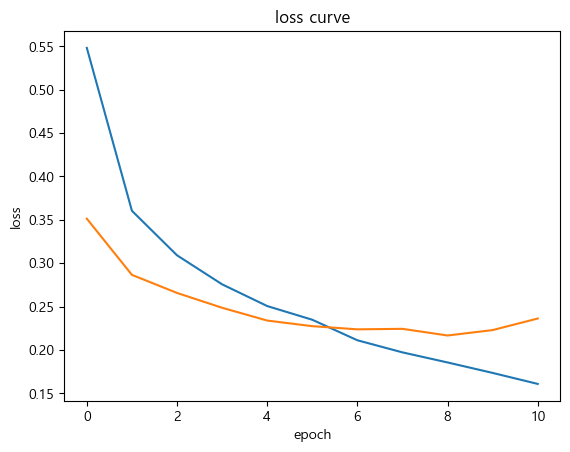

In [20]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve')
plt.show()

In [21]:
# 테스트 데이터 평가
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9152 - loss: 0.2418


[0.24183489382266998, 0.9151999950408936]

In [22]:
import numpy as np
preds = model.predict(test_scaled[0:1]) # 예측 (softmax로 10개의 클래스 확률 반환)
np.argmax(preds) # 9번

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

classes[np.argmax(preds)] # 첫번째 사진의 예측 값은 앵클 부츠!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


'앵클 부츠'

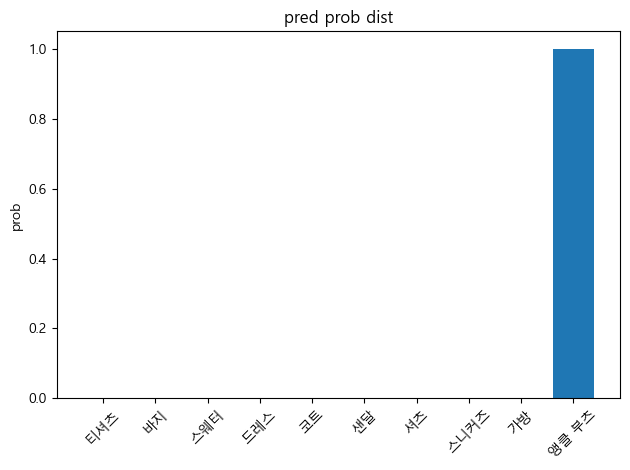

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9152 - loss: 0.2418


[0.24183489382266998, 0.9151999950408936]

In [ ]:
plt.bar(range(1, 11), preds[0])
plt.xticks(range(1, 11), classes, rotation=45)
plt.ylabel('prob')
plt.title('pred prob dist')
plt.tight_layout()
plt.show()

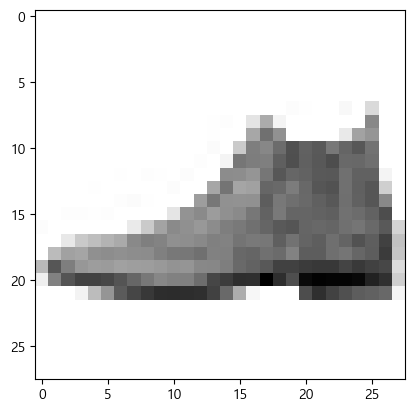

In [33]:
# 맞는지 확인하기
plt.imshow(test_scaled[0], cmap='gray_r')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
예측 클래스 :  바지


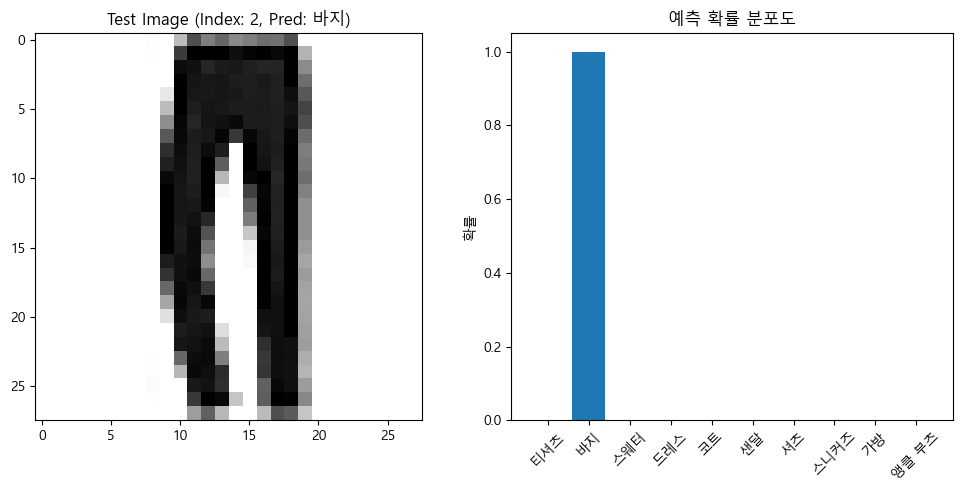

In [ ]:
import matplotlib.pyplot as plt
import platform

# OS에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 예측기
def predict_plot(n):
    preds = model.predict(test_scaled[n:n+1])
    print("예측 클래스 : ", classes[np.argmax(preds)])

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(test_scaled[n], cmap='gray_r')
    axes[0].set_title(f"Test Image (Index: {n}, Pred: {classes[np.argmax(preds)]})")

    axes[1].bar(range(1, 11), preds[0])
    axes[1].set_xticks(range(1, 11))
    axes[1].set_xticklabels(classes, rotation=45)
    axes[1].set_ylabel('확률')
    axes[1].set_title('예측 확률 분포도')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
예측 클래스 :  샌달


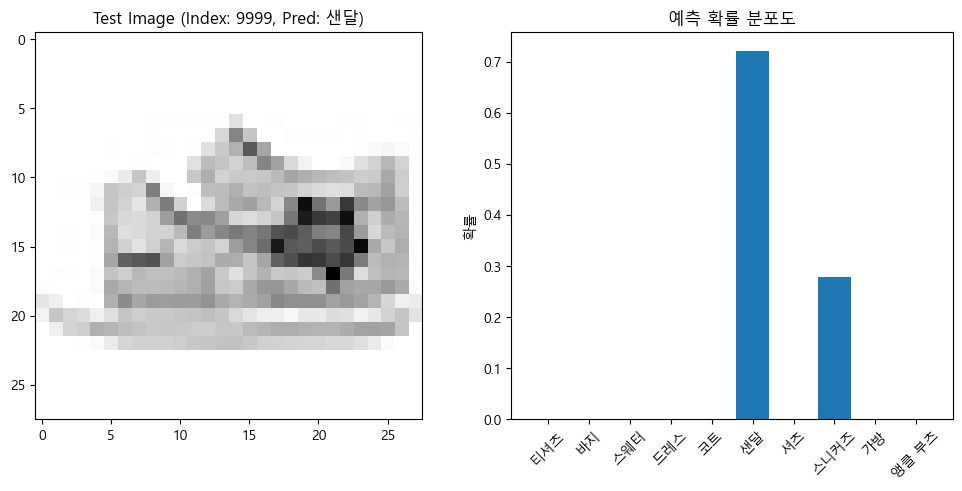

In [51]:
test_scaled.shape
predict_plot(9999)

In [46]:
preds = model.predict(test_scaled[0:1]) 
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[1.8459145e-10, 2.9517316e-11, 3.0701133e-10, 1.0270646e-11,
        2.9515963e-11, 1.9983056e-06, 1.1654035e-10, 8.1941907e-05,
        2.4271250e-11, 9.9991608e-01]], dtype=float32)